In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import matplotlib.image as mpimg
import tensorflow as tf
import os
import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import OrdinalEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv2D, MaxPooling2D, Flatten, GlobalAveragePooling2D
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
import cv2
import warnings
import pickle
from pathlib import Path
warnings.filterwarnings('ignore')

c:\Users\USER\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
train_image = []
train_file = []
train_target = []

test_image = []
test_file = []
test_target = []

p = Path(r"C:\Hacktiv9\FTDS-042-HCK-group-001\build\crop")

for f in p.iterdir():
    if f.is_file():
        if "TR__" in f.name:
                train_file.append(f.name)
                train_image.append(mpimg.imread(f))
                if "TR__ovale" in f.name:
                     train_target.append("ovale")
                elif "TR__rectangular" in f.name:
                     train_target.append("rectangular")
                elif "TR__square" in f.name:
                     train_target.append("square")
                elif "TR__round" in f.name:
                     train_target.append("round")

        elif "TE__" in f.name:
                test_file.append(f.name)
                test_image.append(mpimg.imread(f))
                if "TE__ovale" in f.name:
                     test_target.append("ovale")
                elif "TE__rectangular" in f.name:
                     test_target.append("rectangular")
                elif "TE__square" in f.name:
                     test_target.append("square")
                elif "TE__round" in f.name:
                     test_target.append("round")

data_train = {"file": train_file,
              "image": train_image,
              "target": train_target}

data_test = {"file": test_file,
              "image": test_image,
              "target": test_target}

df_train = pd.DataFrame(data_train)
df_test = pd.DataFrame(data_test)
df_train

,file,image,target
0,TR__ovale__15.jpg,"[[[184, 180, 195], [184, 180, 195], [184, 180,...",ovale
1,TR__ovale__16.jpg,"[[[126, 155, 161], [125, 154, 160], [126, 153,...",ovale
2,TR__ovale__17.jpg,"[[[139, 139, 137], [140, 140, 138], [138, 138,...",ovale
3,TR__ovale__18.jpg,"[[[19, 3, 48], [26, 10, 57], [34, 16, 66], [40...",ovale
4,TR__ovale__22.jpg,"[[[166, 180, 183], [166, 180, 183], [167, 181,...",ovale
...,...,...,...
921,TR__square__square 277.jpg,"[[[12, 12, 14], [12, 12, 14], [12, 12, 14], [1...",square
922,TR__square__square 278.jpg,"[[[73, 87, 12], [74, 88, 13], [60, 77, 0], [62...",square
923,TR__square__square 279.jpg,"[[[90, 103, 135], [90, 103, 135], [91, 105, 13...",square
924,TR__square__square 280.jpg,"[[[212, 198, 187], [212, 198, 187], [212, 198,...",square


In [3]:
df_test

,file,image,target
0,TE__ovale__ovale t1.jpg,"[[[187, 154, 100], [187, 156, 101], [184, 152,...",ovale
1,TE__ovale__ovale t10.jpg,"[[[252, 248, 249], [252, 248, 249], [252, 248,...",ovale
2,TE__ovale__ovale t100.jpg,"[[[134, 114, 63], [134, 114, 63], [136, 113, 6...",ovale
3,TE__ovale__ovale t101.jpg,"[[[140, 167, 194], [140, 167, 194], [140, 167,...",ovale
4,TE__ovale__ovale t102.jpg,"[[[21, 34, 25], [21, 34, 25], [21, 34, 25], [2...",ovale
...,...,...,...
380,TE__square__square t95.jpg,"[[[41, 29, 17], [41, 29, 17], [42, 28, 19], [4...",square
381,TE__square__square t96.jpg,"[[[3, 3, 3], [3, 3, 3], [3, 3, 3], [3, 3, 3], ...",square
382,TE__square__square t97.jpg,"[[[32, 54, 5], [32, 54, 5], [32, 55, 3], [32, ...",square
383,TE__square__square t98.jpg,"[[[209, 200, 195], [209, 200, 195], [209, 200,...",square


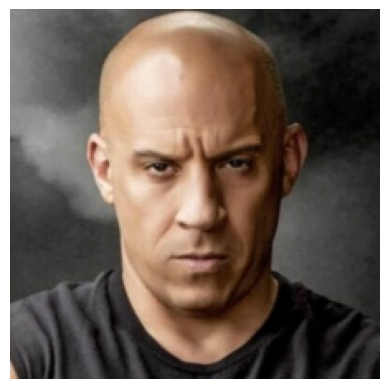

In [4]:
test_image = df_train["image"].iloc[2]
plt.imshow(test_image)
plt.axis("off")
plt.show()

In [5]:
X_val, X_test, y_val, y_test = train_test_split(df_test["image"], df_test["target"], test_size=0.5, random_state=42)
X_val = np.stack(X_val.to_numpy()).astype(np.uint8)
X_test = np.stack(X_test.to_numpy()).astype(np.uint8)
X_train = np.stack(df_train["image"].to_numpy()).astype(np.uint8)
y_train = df_train["target"]

print('Train Size : ', X_train.shape, X_train.dtype)
print('Val Size   : ', X_val.shape, X_val.dtype)
print('Test Size  : ', X_test.shape, X_test.dtype)
print('Train Size : ', y_train.shape, y_train.dtype)
print('Val Size   : ', y_val.shape, y_val.dtype)
print('Test Size  : ', y_test.shape, y_test.dtype)

Train Size :  (926, 224, 224, 3) uint8
Val Size   :  (192, 224, 224, 3) uint8
Test Size  :  (193, 224, 224, 3) uint8
Train Size :  (926,) str
Val Size   :  (192,) str
Test Size  :  (193,) str


In [6]:
encoder_label = OrdinalEncoder(categories=[["ovale", "rectangular", "round", "square"]])
encoder_label.fit(y_train.to_frame())
y_train_encoded = encoder_label.transform(y_train.to_frame())
y_val_encoded = encoder_label.transform(y_val.to_frame())
y_test_encoded = encoder_label.transform(y_test.to_frame())

In [7]:
# Feature Scaling

X_train = X_train / 255.
X_val = X_val / 255.
X_test = X_test / 255.

In [8]:
# Clear Session
seed = 20
tf.keras.backend.clear_session()
np.random.seed(seed)
tf.random.set_seed(seed)

#CNN Iprovement
# Create Sequential API model

model = Sequential()
model.add(Conv2D(32, (3,3), padding="same", activation='relu', kernel_regularizer=l2(1e-4),  input_shape=(224, 224,3)))
model.add(MaxPooling2D(2, 2))
model.add(Conv2D(64, (3,3), padding="same", activation='relu', kernel_regularizer=l2(1e-4)))
model.add(MaxPooling2D(2, 2))
model.add(Conv2D(128, (3,3),padding="same", activation='relu', kernel_regularizer=l2(1e-4)))
model.add(MaxPooling2D(2, 2))
model.add(GlobalAveragePooling2D())
model.add(Dropout(0.5))
model.add(Dense(256, activation='relu'))
model.add(Dense(4, activation='softmax'))

# Compile
model.compile(loss='sparse_categorical_crossentropy',
              optimizer=Adam(learning_rate=5e-4),
              metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 127,300 (497.27 KB)

 Trainable params: 127,300 (497.27 KB)

 Non-trainable params: 0 (0.00 B)

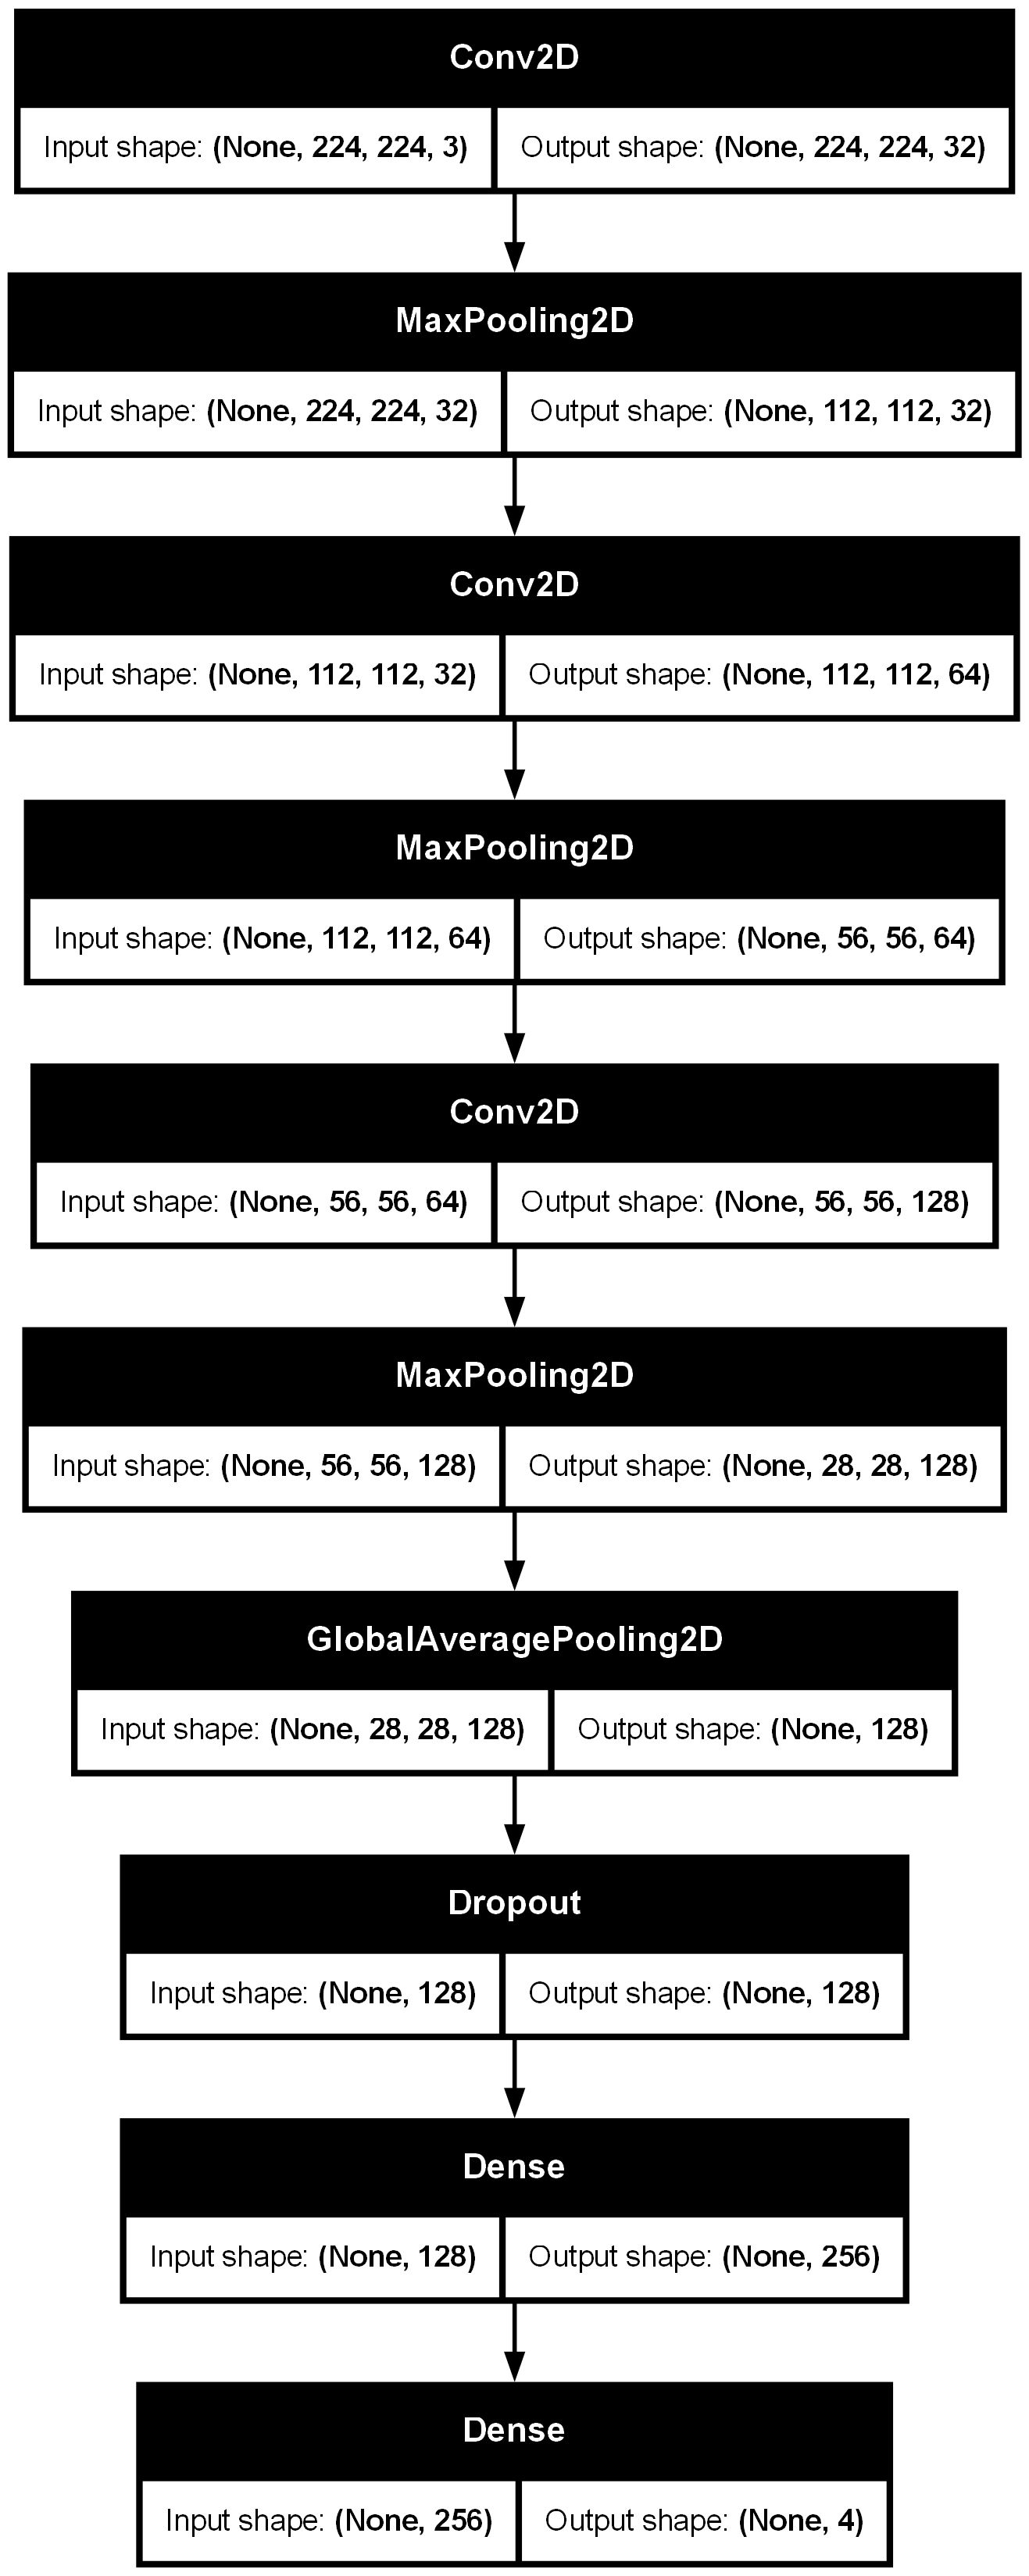

In [9]:
# Display model architecture
tf.keras.utils.plot_model(model, show_shapes=True)

In [10]:
# Train the Model

history_seq = model.fit(X_train, y_train_encoded, epochs=100, validation_data=(X_val, y_val_encoded))

Epoch 1/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 0.2765 - loss: 1.3938 - val_accuracy: 0.1719 - val_loss: 1.4495
Epoch 2/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.3002 - loss: 1.3919 - val_accuracy: 0.1719 - val_loss: 1.4279
Epoch 3/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.2970 - loss: 1.3869 - val_accuracy: 0.1719 - val_loss: 1.4294
Epoch 4/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.3024 - loss: 1.3855 - val_accuracy: 0.1719 - val_loss: 1.4370
Epoch 5/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.3013 - loss: 1.3860 - val_accuracy: 0.1719 - val_loss: 1.4215
Epoch 6/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.2991 - loss: 1.3828 - val_accuracy: 0.1719 - val_loss: 1.4448
Epoch 7/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.3013 - loss: 1.3834 - val_accuracy: 0.1719 - val_loss: 1.4218
Epoch 8/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.3045 - loss: 1.3768 - val_accuracy: 0.1719 - v

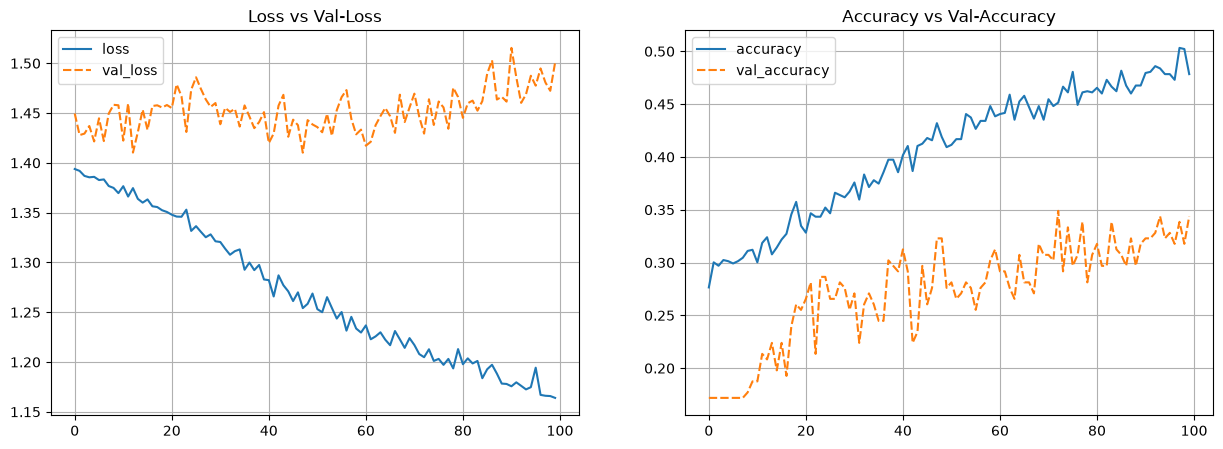

In [11]:
# Plot Training Results

history_seq_df = pd.DataFrame(history_seq.history)

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.lineplot(data=history_seq_df[['loss', 'val_loss']])
plt.grid()
plt.title('Loss vs Val-Loss')

plt.subplot(1, 2, 2)
sns.lineplot(data=history_seq_df[['accuracy', 'val_accuracy']])
plt.grid()
plt.title('Accuracy vs Val-Accuracy')
plt.show()

In [12]:
# Check the performance of test-set
class_names = ["ovale", "rectangular", "round", "square"]
# Get the probability
y_pred_proba = model.predict(X_test)

# Get class with maximum probability
y_pred_test = np.argmax(y_pred_proba, axis=-1)

# Display Classification Report
print(classification_report(y_test_encoded, y_pred_test, target_names=np.array(class_names)))

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 175ms/step
              precision    recall  f1-score   support

       ovale       0.50      0.25      0.33        60
 rectangular       0.37      0.20      0.26        55
       round       0.24      0.70      0.36        30
      square       0.33      0.31      0.32        48

    accuracy                           0.32       193
   macro avg       0.36      0.37      0.32       193
weighted avg       0.38      0.32      0.31       193



In [13]:
# Model is saved to desired folder
with open("model.pkl", 'wb') as file_1:
  pickle.dump(model, file_1)